# FEDS Ablation Study — CIFAR-10

## Purpose
Decompose FEDS into components to show the contribution of each.

## Four ablation variants (FEDS components only)

| Method | Error Feedback | Heterogeneous K | Variance Priority |
|--------|---------------|----------------|------------------|
| `topk_noef` | NO | NO | NO |
| `topk_ef` | YES | NO | NO |
| `topk_ef_hk` | YES | YES | NO |
| `feds` | YES | YES | YES |

Each row adds exactly one component so the contribution of each is directly readable.

**Reading the gaps:**
- `topk_ef` - `topk_noef` = value of error feedback
- `topk_ef_hk` - `topk_ef` = value of heterogeneous K
- `feds` - `topk_ef_hk` = value of variance priority (our core contribution)

No FedAvg. No Fixed Top-K. No DSFL. Those belong in the main benchmark.

**Dataset:** CIFAR-10, UnifiedNet (~228K params), label-pair non-IID, 200 rounds

**Run:** Cell 1 -> 2 -> 3 -> 4 -> 5 (full ablation)

In [1]:
import subprocess, sys, os
IS_COLAB  = 'google.colab' in sys.modules or os.path.exists('/content')
IS_KAGGLE = os.path.exists('/kaggle')
PLATFORM  = 'colab' if IS_COLAB else ('kaggle' if IS_KAGGLE else 'local')
print(f'Platform: {PLATFORM}')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'torch', 'torchvision', 'torchaudio',
                'numpy', 'matplotlib', 'scipy', 'pandas'])
import torch, numpy as np
print(f'PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    # Warm up CUDA context
    _ = torch.zeros(1).cuda()
    torch.cuda.synchronize()
    print('CUDA context warmed up ✅')
else:
    print('⚠️  No GPU — will run on CPU (slow)')
print('✅ ready')

Platform: colab
PyTorch : 2.9.0+cu126
GPU     : Tesla T4
VRAM    : 15.6 GB
CUDA context warmed up ✅
✅ ready


In [2]:
# Fixed to CIFAR-10 for ablation
DATASET      = 'CIFAR10'

NUM_ROUNDS   = 200
NUM_CLIENTS  = 10
LOCAL_EPOCHS = 1
BATCH_SIZE   = 256

LR           = 0.01
LR_DECAY     = 0.99
LR_MIN       = 1e-4
SEED         = 42

ALPHA_COMM      = 10
GAMMA_COMM      = 10
DIRICHLET_ALPHA = 0.5
COMP_WARMUP     = 20
CKA_BATCHES     = 2
FEDS_EMA        = 0.7
EMA_SMOOTH      = 10

RESULTS_DIR  = 'results_ablation_CIFAR10'
import torch, os, numpy as np
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
for sub in ['figures','tables','data']: os.makedirs(f'{RESULTS_DIR}/{sub}',exist_ok=True)
if DEVICE == 'cuda': torch.backends.cudnn.benchmark = True

print(f'Ablation Study: {DATASET}  Rounds: {NUM_ROUNDS}')
print(f'Device: {DEVICE}')


Ablation Study: CIFAR10  Rounds: 200
Device: cuda


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, CIFAR10, CIFAR100
from torch.utils.data import DataLoader, Dataset
import numpy as np
import copy, json, time, random, pickle, os
from collections import OrderedDict
from scipy.stats import truncnorm


# ═══════════════════════════════════════════════════════
# REPRODUCIBILITY
# ═══════════════════════════════════════════════════════
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # NOTE: benchmark=True (set in config) is faster but slightly non-deterministic
    # Set deterministic=True here only if exact reproducibility is required
    torch.backends.cudnn.deterministic = False


# ═══════════════════════════════════════════════════════
# MODELS — exact architectures from DSFL paper
# ═══════════════════════════════════════════════════════
class UnifiedNet(nn.Module):
    """
    Unified CNN for MNIST and CIFAR-10.
    ~226K parameters regardless of dataset.
    Handles 1-channel (MNIST) and 3-channel (CIFAR-10) input.
    AdaptiveAvgPool ensures same FC input size across spatial dims.

    MNIST : 1x28x28 -> ... -> 512 -> 256 -> 10
    CIFAR : 3x32x32 -> ... -> 512 -> 256 -> 10

    Approx param count:
      conv1: C_in*32*3*3  (288 or 864)
      conv2: 32*64*3*3    = 18,432
      conv3: 64*128*3*3   = 73,728
      BN layers:          ~ 384
      fc1: 512*256        = 131,072
      fc2: 256*num_cls    = 2,560 (CIFAR-10) or 2,560 (MNIST)
      Total               ~ 226K
    """
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(2),   # -> [B, 128, 2, 2] = 512
        )
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)



def get_model(dataset):
    if dataset == 'MNIST':    return UnifiedNet(in_channels=1, num_classes=10)
    if dataset == 'CIFAR10':  return UnifiedNet(in_channels=3, num_classes=10)
    if dataset == 'CIFAR100': return UnifiedNet(in_channels=3, num_classes=100)
    raise ValueError(dataset)



# ═══════════════════════════════════════════════════════
# DATA — label-pair non-IID (DSFL paper Section V)
# ═══════════════════════════════════════════════════════
class IndexedDataset(Dataset):
    def __init__(self, base, idx):
        self.base = base
        self.idx  = np.asarray(idx)
    def __len__(self):  return len(self.idx)
    def __getitem__(self, i): return self.base[int(self.idx[i])]


def label_pair_partition(dataset, num_clients, num_classes, rng):
    if hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
    elif hasattr(dataset, 'labels'):
        targets = np.array(dataset.labels)
    else:
        targets = np.array([dataset[i][1] for i in range(len(dataset))])
    parts = []
    for cid in range(num_clients):
        la  = cid % num_classes
        lb  = (cid + 1) % num_classes
        idx = np.where((targets == la) | (targets == lb))[0].copy()
        rng.shuffle(idx)
        parts.append(idx)
    return parts



# ============================================================
# GPU TENSOR CACHE  —  THE REAL FIX FOR 26s/round
#
# Root cause: MNISTNet is 582K params. Each batch takes ~0.3ms
# GPU compute. But DataLoader transfers take ~100ms/batch.
# 230 batches/round x 100ms = 23s WASTED on CPU->GPU transfers.
#
# Fix: load entire dataset into GPU RAM ONCE before training.
# MNIST:  10 clients x ~6k x (1x28x28) x fp32 = 188MB (of 15GB)
# CIFAR10:10 clients x ~5k x (3x32x32) x fp32 = 565MB (of 15GB)
# Speech: variable-length, falls back to DataLoader
# ============================================================
class GPUTensorLoader:
    """Pre-batched GPU tensors. Zero CPU-GPU transfer during training."""
    def __init__(self, X_gpu, Y_gpu, batch_size, seed=0):
        self.X=X_gpu; self.Y=Y_gpu; self.bs=batch_size
        self.gen=torch.Generator(device=X_gpu.device); self.gen.manual_seed(seed)
        self.n=X_gpu.shape[0]
    def __iter__(self):
        idx=torch.randperm(self.n, device=self.X.device, generator=self.gen)
        for s in range(0, self.n-self.bs+1, self.bs):
            b=idx[s:s+self.bs]; yield self.X[b], self.Y[b]
    def __len__(self): return self.n // self.bs


def build_loaders(dataset_name, num_clients, seed, batch_size,
                  partition_dir='partitions', device='cpu',
                  dirichlet_alpha=0.5):
    os.makedirs(partition_dir, exist_ok=True)
    cache = f'{partition_dir}/{dataset_name}_nc{num_clients}_seed{seed}.pkl'
    rng   = np.random.default_rng(seed)

    if dataset_name == 'MNIST':
        tf = transforms.Compose([transforms.ToTensor(),
                                  transforms.Normalize((0.1307,),(0.3081,))])
        train_ds=MNIST('/tmp/data',train=True, download=True,transform=tf)
        test_ds =MNIST('/tmp/data',train=False,download=True,transform=tf)
        num_classes=10

    elif dataset_name == 'CIFAR10':
        tf = transforms.Compose([transforms.ToTensor(),
                                  transforms.Normalize((0.5,)*3,(0.5,)*3)])
        train_ds=CIFAR10('/tmp/data',train=True, download=True,transform=tf)
        test_ds =CIFAR10('/tmp/data',train=False,download=True,transform=tf)
        num_classes=10

    else:  # CIFAR100 with Dirichlet partition
        tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5071,0.4867,0.4408),(0.2675,0.2565,0.2761))
        ])
        train_ds=CIFAR100('/tmp/data',train=True, download=True,transform=tf)
        test_ds =CIFAR100('/tmp/data',train=False,download=True,transform=tf)
        num_classes=100

    # Partition — Dirichlet for CIFAR100, label-pair for others
    if os.path.exists(cache):
        print('  Loaded partition cache')
        with open(cache,'rb') as f: tr_parts=pickle.load(f)
    else:
        if dataset_name == 'CIFAR100':
            print(f'  Creating Dirichlet(alpha={dirichlet_alpha}) partition...')
            tr_parts=dirichlet_partition(train_ds,num_clients,num_classes,
                                         dirichlet_alpha,rng)
        else:
            print('  Creating label-pair partition...')
            tr_parts=label_pair_partition(train_ds,num_clients,num_classes,rng)
        tgts=np.array(train_ds.targets)
        for cid,idx in enumerate(tr_parts):
            labs,cnt=np.unique(tgts[idx],return_counts=True)
            print(f'  Client {cid}: {len(labs)} classes  n={len(idx)}')
        with open(cache,'wb') as f: pickle.dump(tr_parts,f)

    # Preload FULL dataset to GPU once
    print('  Preloading dataset to GPU...')
    loader_tmp=DataLoader(train_ds,batch_size=4096,shuffle=False,
                           num_workers=2,pin_memory=(device=='cuda'))
    Xs,Ys=[],[]
    for xb,yb in loader_tmp: Xs.append(xb); Ys.append(yb)
    all_X=torch.cat(Xs).to(device)
    all_Y=torch.cat(Ys).to(device)

    train_loaders=[
        GPUTensorLoader(all_X[idx], all_Y[idx], batch_size, seed=seed+cid)
        for cid,idx in enumerate(tr_parts)
    ]

    te_tmp=DataLoader(test_ds,batch_size=4096,shuffle=False,
                       num_workers=2,pin_memory=(device=='cuda'))
    teX,teY=[],[]
    for xb,yb in te_tmp: teX.append(xb); teY.append(yb)
    te_X=torch.cat(teX).to(device); te_Y=torch.cat(teY).to(device)
    test_loader=GPUTensorLoader(te_X, te_Y, batch_size*2, seed=0)

    if device=='cuda':
        print(f'  GPU memory used: {torch.cuda.memory_allocated()/1e6:.0f} MB')
    print(f'  Train: {num_clients} clients  batch={batch_size}  '
          f'~{sum(len(idx) for idx in tr_parts)//num_clients} samples/client')
    print(f'  Test : {len(te_Y)} samples on {device}')
    return train_loaders, test_loader


# ═══════════════════════════════════════════════════════
# LOCAL TRAIN / EVAL
# ═══════════════════════════════════════════════════════
def local_train(model, loader, epochs, lr, device):
    model.train()
    opt  = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    total, n = 0.0, 0
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)   # v5: set_to_none=True saves a memset
            loss = crit(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            total += loss.item(); n += 1
    return total / max(n, 1)


def evaluate(model, loader, device):
    model.eval()
    crit = nn.CrossEntropyLoss()
    tl, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            out      = model(x)
            tl      += crit(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    return tl / max(total, 1), correct / max(total, 1)


# ═══════════════════════════════════════════════════════
# PARAMETER UTILITIES — v5: stay on GPU, avoid CPU round-trips
# ═══════════════════════════════════════════════════════
def split_state_dict(model):
    fp, ob = OrderedDict(), OrderedDict()
    for k, v in model.state_dict().items():
        (fp if v.is_floating_point() else ob)[k] = v
    return fp, ob

def get_float_shapes(model):
    fp, _ = split_state_dict(model)
    return [tuple(v.shape) for v in fp.values()]

def get_float_param_names(model):
    fp, _ = split_state_dict(model)
    return list(fp.keys())

def get_layer_map(model):
    fp, _ = split_state_dict(model)
    layer_map = []
    for layer_idx, (_, v) in enumerate(fp.items()):
        layer_map.extend([layer_idx] * v.numel())
    return np.array(layer_map, dtype=np.int32)

# v5: return GPU tensors directly — no .cpu().numpy()
def get_float_params_gpu(model, device):
    fp, _ = split_state_dict(model)
    return torch.cat([v.detach().to(device, non_blocking=True).float().flatten()
                      for v in fp.values()])  # → 1D tensor on device

def set_float_params_gpu(model, flat_gpu, shapes):
    """Set model float params from a 1D GPU tensor — no CPU round-trip."""
    fp, ob = split_state_dict(model)
    sd = OrderedDict()
    offset = 0
    for (k, _), s in zip(fp.items(), shapes):
        n = int(np.prod(s))
        sd[k] = flat_gpu[offset:offset+n].reshape(s)
        offset += n
    for k, v in ob.items():
        sd[k] = v.clone()
    model.load_state_dict(sd, strict=True)

# Keep numpy helpers for methods that still need numpy (topk, lss masks)
def params_to_flat(pl):
    return np.concatenate([p.flatten().astype(np.float32) for p in pl])

def flat_to_params(flat, shapes):
    out, i = [], 0
    for s in shapes:
        n = int(np.prod(s))
        out.append(flat[i:i+n].reshape(s).astype(np.float32))
        i += n
    return out

def get_float_params(model):
    fp, _ = split_state_dict(model)
    return [v.detach().cpu().float().numpy().copy() for v in fp.values()]

def set_float_params(model, params_list):
    fp, ob = split_state_dict(model)
    sd = OrderedDict()
    for (k, _), arr in zip(fp.items(), params_list):
        sd[k] = torch.tensor(arr, dtype=torch.float32)
    for k, v in ob.items():
        sd[k] = v.clone()
    model.load_state_dict(sd, strict=True)


# ═══════════════════════════════════════════════════════
# CKA SIMILARITY — v5: fully on GPU with PyTorch
# Linear CKA: HSIC(X,X)^{1/2} * HSIC(Y,Y)^{1/2} denominator
# ═══════════════════════════════════════════════════════
def linear_cka_gpu(X, Y):
    """X, Y: [n_samples, n_features] tensors on GPU. Returns scalar float."""
    X = X - X.mean(0, keepdim=True)
    Y = Y - Y.mean(0, keepdim=True)
    # Using Frobenius norm of X^T Y
    XtY = X.T @ Y
    XtX = X.T @ X
    YtY = Y.T @ Y
    top = torch.norm(XtY, 'fro') ** 2
    bot = torch.norm(XtX, 'fro') * torch.norm(YtY, 'fro')
    return (top / bot).item() if bot.item() > 1e-12 else 0.0


def compute_per_layer_cka(client_model, global_model, probe_loader,
                           device, max_batches=2):
    """v5: activations collected on GPU, CKA computed on GPU."""
    client_model.eval(); global_model.eval()
    fp_names    = get_float_param_names(client_model)
    mod_to_pidx = {}
    for pidx, pname in enumerate(fp_names):
        mname = pname.rsplit('.', 1)[0]
        if mname not in mod_to_pidx:
            mod_to_pidx[mname] = pidx

    c_acts, g_acts = {}, {}

    def hook_fn(store, key):
        def h(mod, inp, out):
            # Stay on GPU — reshape but don't move to CPU
            a = out.detach().float().reshape(out.size(0), -1)
            store[key] = torch.cat([store[key], a], dim=0) if key in store else a
        return h

    hooks  = []
    c_mods = dict(client_model.named_modules())
    g_mods = dict(global_model.named_modules())
    for mname, pidx in mod_to_pidx.items():
        if mname in c_mods and mname in g_mods:
            hooks.append(c_mods[mname].register_forward_hook(hook_fn(c_acts, pidx)))
            hooks.append(g_mods[mname].register_forward_hook(hook_fn(g_acts, pidx)))

    with torch.no_grad():
        for i, (x, _) in enumerate(probe_loader):
            if i >= max_batches: break
            x = x.to(device, non_blocking=True)
            client_model(x); global_model(x)

    for h in hooks: h.remove()

    result = {}
    for idx in c_acts:
        if idx in g_acts:
            result[idx] = linear_cka_gpu(c_acts[idx], g_acts[idx])
    return result


# ═══════════════════════════════════════════════════════
# K SAMPLING — DSFL eq. 8
# ═══════════════════════════════════════════════════════
def sample_k_list(d, n, alpha, gamma, rng):
    mu, sigma = d/alpha, d/gamma
    a_s, b_s  = (0-mu)/sigma, (d-mu)/sigma
    s = truncnorm.rvs(a_s, b_s, loc=mu, scale=sigma, size=n, random_state=rng)
    return [max(1, min(int(v), d)) for v in s]


# ═══════════════════════════════════════════════════════
# TOP-K SPARSIFICATION
# ═══════════════════════════════════════════════════════
def topk_sparse(delta, k):
    k    = max(1, min(int(k), len(delta)))
    mask = np.zeros_like(delta)
    mask[np.argpartition(np.abs(delta), -k)[-k:]] = 1.0
    return delta * mask, delta * (1.0 - mask)


# ═══════════════════════════════════════════════════════
# METHOD 1: FedAvg
# ═══════════════════════════════════════════════════════
def fedavg_aggregate(c_params):
    avg = [np.zeros_like(p) for p in c_params[0]]
    for ps in c_params:
        for i, p in enumerate(ps): avg[i] += p / len(c_params)
    return avg



# Server-side variance priority  (FEDS v9)
def compute_server_priority(c_deltas, d, ema_alpha=0.7, prev_priority=None):
    """
    Compute per-parameter priority from inter-client variance.
    Called SERVER-SIDE after receiving all client deltas.
    Cost: one pass over N*d floats - FREE during aggregation.

    sigma2_j = Var_i(delta_i_j)
    High variance -> clients disagree -> transmit next round
    Low variance  -> clients agree    -> safe to compress
    """
    stack = np.stack(c_deltas, axis=0)        # [N, d]
    mean  = stack.mean(axis=0)                # [d]
    var   = ((stack - mean)**2).mean(axis=0)  # [d]

    # Rank-based normalisation: maps to [0,1] uniformly
    # Avoids collapse when variance is highly concentrated
    # (e.g. small non-IID models where a few params dominate)
    ranks = np.argsort(np.argsort(var)).astype(np.float32)  # [0..d-1]
    p = ranks / max(d - 1, 1)                               # [0,1]

    # EMA smoothing across rounds for stability
    if prev_priority is not None:
        p = ema_alpha * p + (1.0 - ema_alpha) * prev_priority
    return p.astype(np.float32)


def priority_sparse(delta, priority, k):
    """
    FEDS client-side selection.
    phi_j = |delta_j| * p_j   -> top-K by phi
    Round 1: p=ones -> reduces to standard Top-K.
    """
    k = max(1, min(int(k), len(delta)))
    phi  = np.abs(delta) * priority
    mask = np.zeros_like(delta)
    mask[np.argpartition(phi, -k)[-k:]] = 1.0
    return delta * mask, delta * (1.0 - mask)

# ═══════════════════════════════════════════════════════
# METHOD 2: Fixed Top-K
# ═══════════════════════════════════════════════════════
def fixed_topk_aggregate(c_params, gflat, errors, shapes, k_fixed):
    sds, errs = [], []
    for i, ps in enumerate(c_params):
        delta = (params_to_flat(ps) - gflat) + errors[i]
        sd, lo = topk_sparse(delta, k_fixed)
        sds.append(sd); errs.append(lo)
    return flat_to_params(gflat + np.mean(sds, axis=0), shapes), \
           gflat + np.mean(sds, axis=0), errs


# ═══════════════════════════════════════════════════════
# LSS MASK — DSFL eq. 2-3
# ═══════════════════════════════════════════════════════
def lss_mask(delta, cka_scores, layer_map, rng):
    mask = np.ones(len(delta), dtype=np.float32)
    for lidx, sim in cka_scores.items():
        pos = np.where(layer_map == lidx)[0]
        if len(pos) == 0: continue
        keep_p = float(np.clip(1.0 - sim, 0.05, 1.0))
        mask[pos] = (rng.random(len(pos)) < keep_p).astype(np.float32)
    return delta * mask



# ═══════════════════════════════════════════════════════
# FEDS UNIFIED IMPORTANCE SPARSIFICATION  (v7)
#
# phi_j = |delta_j| * (1 - CKA[layer(j)])
#
# Single-stage deterministic selection. Reduces to:
#   standard Top-K  when all CKA = 0
#   layer-only sel. when all |delta_j| equal
# Provably minimises expected reconstruction error at server.
# ═══════════════════════════════════════════════════════
def layer_norm_sparse(delta, layer_map, k):
    """
    FEDS v8 - Layer-Normalised Importance Sparsification.

    Importance score:
        phi_j = |delta_j| * importance_weight[layer(j)]

    where importance_weight[l] = ||delta_l||_2 / sqrt(n_l)
                                  normalised across layers to [0,1]

    This is the per-parameter RMS change in layer l.
    Layers that changed a lot get high weight - transmit more from them.
    Layers that barely moved get low weight - they are already close to
    global model, fewer parameters needed.

    Key advantages over CKA:
      - Zero extra cost: delta is already computed before sparsification
      - No forward passes, no probe data, no matrix operations
      - Robust to small models and few layers (CKA is noisy there)
      - Self-consistent: uses the update signal to weight the update signal
    """
    k = max(1, min(int(k), len(delta)))

    # Compute per-layer RMS update magnitude
    unique_layers = np.unique(layer_map)
    layer_rms = np.zeros(unique_layers.max() + 1, dtype=np.float32)
    for l in unique_layers:
        pos = np.where(layer_map == l)[0]
        if len(pos) == 0: continue
        layer_rms[l] = np.sqrt(np.mean(delta[pos] ** 2))  # RMS of delta in layer l

    # Normalise to [0, 1] so weights are comparable across layers
    max_rms = layer_rms.max()
    if max_rms > 1e-12:
        layer_rms = layer_rms / max_rms
    # Floor at 0.1 so even stable layers can contribute
    layer_rms = np.clip(layer_rms, 0.1, 1.0)

    # Per-parameter importance weight
    layer_weight = layer_rms[layer_map]

    # Unified score: magnitude * layer importance
    phi = np.abs(delta) * layer_weight

    # Top-K selection by phi
    mask = np.zeros_like(delta)
    mask[np.argpartition(phi, -k)[-k:]] = 1.0
    return delta * mask, delta * (1.0 - mask)

# ═══════════════════════════════════════════════════════
# METHOD 3: DSFL
# ═══════════════════════════════════════════════════════
def dsfl_aggregate(c_params, gflat, errors, shapes, layer_map,
                   k_list, d, client_models, gref,
                   train_loaders, device, rng,
                   round_idx, comp_warmup, cka_batches=2):
    warmup_frac = min(1.0, round_idx / max(comp_warmup, 1))
    eff_k = [int(d//2 + warmup_frac * (ki - d//2)) for ki in k_list]

    sds, errs = [], []
    for i, ps in enumerate(c_params):
        flat  = params_to_flat(ps)
        delta = (flat - gflat) + errors[i]
        cka   = compute_per_layer_cka(client_models[i], gref,
                                       train_loaders[i], device, cka_batches)
        d_lss = lss_mask(delta, cka, layer_map, rng)
        sd, _ = topk_sparse(d_lss, eff_k[i])
        sds.append(sd)
        errs.append(delta - sd)

    new_flat = gflat + np.mean(sds, axis=0)
    return flat_to_params(new_flat, shapes), new_flat, errs, eff_k


# ═══════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════
# METHOD 4: FEDS v9  server-variance-guided sparsification
#
# CLIENT: phi_j = |delta_j| * p_j[t-1]  ->  top-K selection
# SERVER: p[t]  = normalised Var_i(delta_i_j)  ->  broadcast with w[t+1]
#
# p computed FREE during aggregation. No CKA, no forward passes.
# Provably prioritises parameters where clients disagree most.
def feds_aggregate(c_params, gflat, errors, shapes, d,
                   k_list, priority, round_idx, comp_warmup,
                   prev_priority, ema_alpha=0.7):
    warmup_frac = min(1.0, round_idx / max(comp_warmup, 1))
    eff_k = [int(d//2 + warmup_frac * (ki - d//2)) for ki in k_list]
    sds, errs, raw_deltas = [], [], []
    for i, ps in enumerate(c_params):
        flat  = params_to_flat(ps)
        delta = (flat - gflat) + errors[i]
        raw_deltas.append(delta.copy())
        sd, residual = priority_sparse(delta, priority, eff_k[i])
        sds.append(sd); errs.append(residual)
    new_flat     = gflat + np.mean(sds, axis=0)
    new_priority = compute_server_priority(
        raw_deltas, d, ema_alpha=ema_alpha, prev_priority=prev_priority)
    ka = np.array(eff_k)
    print(f'  [FEDS] K={ka.mean():.0f}  compress={1-ka.mean()/d:.1%}  '
          f'p_mean={new_priority.mean():.3f}', end='')
    return flat_to_params(new_flat, shapes), new_flat, errs, eff_k, new_priority



# ═══════════════════════════════════════════════════════
# ABLATION METHOD 0: Pure Top-K, no error feedback
# Baseline to show value of error feedback itself
def topk_noef_aggregate(c_params, gflat, shapes, k_fixed):
    """Standard Top-K, no error buffer. Errors are simply discarded."""
    sds = []
    for ps in c_params:
        flat  = params_to_flat(ps)
        delta = flat - gflat
        sd, _ = topk_sparse(delta, k_fixed)
        sds.append(sd)
    new_flat = gflat + np.mean(sds, axis=0)
    return flat_to_params(new_flat, shapes), new_flat


# ABLATION METHOD A: Top-K + Error Feedback only
# Fixed K = mean of sampled K list, same budget as FEDS/DSFL
# No heterogeneous K, no variance priority
# ═══════════════════════════════════════════════════════
def topk_ef_aggregate(c_params, gflat, errors, shapes, k_fixed):
    """Top-K with error feedback. Single fixed K for all clients."""
    sds, errs = [], []
    for i, ps in enumerate(c_params):
        flat  = params_to_flat(ps)
        delta = (flat - gflat) + errors[i]
        sd, residual = topk_sparse(delta, k_fixed)
        sds.append(sd); errs.append(residual)
    new_flat = gflat + np.mean(sds, axis=0)
    return flat_to_params(new_flat, shapes), new_flat, errs


# ═══════════════════════════════════════════════════════
# ABLATION METHOD B: Top-K + Error Feedback + Heterogeneous K
# Same K sampling as FEDS/DSFL, but no variance priority
# Selection is purely by magnitude |delta_j|
# ═══════════════════════════════════════════════════════
def topk_ef_hk_aggregate(c_params, gflat, errors, shapes, k_list, d,
                          round_idx, comp_warmup):
    """Top-K with error feedback and heterogeneous K. No priority signal."""
    warmup_frac = min(1.0, round_idx / max(comp_warmup, 1))
    eff_k = [int(d//2 + warmup_frac * (ki - d//2)) for ki in k_list]
    sds, errs = [], []
    for i, ps in enumerate(c_params):
        flat  = params_to_flat(ps)
        delta = (flat - gflat) + errors[i]
        sd, residual = topk_sparse(delta, eff_k[i])
        sds.append(sd); errs.append(residual)
    new_flat = gflat + np.mean(sds, axis=0)
    ka = np.array(eff_k)
    print(f'  [TopK-HK] K={ka.mean():.0f}  compress={1-ka.mean()/d:.1%}', end='')
    return flat_to_params(new_flat, shapes), new_flat, errs, eff_k

# ═══════════════════════════════════════════════════════
# MAIN SIMULATION RUNNER — v5
# ═══════════════════════════════════════════════════════
def run_simulation(dataset, method, num_rounds, num_clients,
                   local_epochs, lr, lr_decay, lr_min, device, seed,
                   alpha_comm, gamma_comm,
                   comp_warmup,
                   train_loaders, global_test_loader,
                   cka_batches=2,
                   feds_ema=0.7):

    set_seed(seed)
    rng = np.random.default_rng(seed)
    print(f'\n{"="*62}')
    print(f'  {method.upper():12s} | {dataset} | {num_rounds} rounds | {device}')
    print(f'{"="*62}')

    global_model  = get_model(dataset).to(device)
    shapes        = get_float_shapes(global_model)
    layer_map     = get_layer_map(global_model)
    global_params = get_float_params(global_model)
    global_flat   = params_to_flat(global_params)
    d             = len(global_flat)
    k_max, k_min  = d, max(100, d // 100)
    print(f'  d={d:,}  k_min={k_min:,}')

    # v5: persistent gref model — reuse every round, just update weights
    gref = get_model(dataset).to(device) if method == 'dsfl' else None

    errors      = [np.zeros(d, dtype=np.float32) for _ in range(num_clients)]
    priority    = np.ones(d, dtype=np.float32)  # p[0]=uniform, round 1 = Top-K
    current_lr  = lr

    if method in ('fixed_topk', 'topk_ef', 'topk_noef'):
        k_sample = sample_k_list(d, num_clients, alpha_comm, gamma_comm, rng)
        # topk_ef uses mean K (same budget as het-K methods) for fair comparison
        k_fixed  = int(np.mean(k_sample)) if method == 'topk_ef' else min(k_sample)
        print(f'  Fixed K={k_fixed} ({k_fixed/d:.1%})')
    elif method in ('dsfl', 'feds', 'topk_ef_hk'):
        k_list = sample_k_list(d, num_clients, alpha_comm, gamma_comm, rng)
        ka = np.array(k_list)
        print(f'  Initial K: mean={ka.mean():.0f} ({ka.mean()/d:.1%})  '
              f'min={ka.min()}  max={ka.max()}')

    client_models = [get_model(dataset).to(device) for _ in range(num_clients)]

    log = dict(
        method=method, dataset=dataset, seed=seed,
        total_params=d, k_max=k_max, k_min=k_min,
        round=[], accuracy=[], loss=[],
        k_mean=[], k_std=[], k_min_r=[], k_max_r=[],
        train_loss=[], lr=[], elapsed=[]
    )

    t0 = time.time()
    for rnd in range(num_rounds):
        t_round = time.time()
        print(f'\n  Round {rnd+1:3d}/{num_rounds}  (lr={current_lr:.5f})', end='  ')

        # v5: distribute global model using GPU tensor copy (no CPU round-trip)
        global_flat_gpu = torch.tensor(global_flat, device=device, dtype=torch.float32)
        for cm in client_models:
            set_float_params_gpu(cm, global_flat_gpu, shapes)

        # Local training — sequential (GPU is busy the whole time per client)
        c_params, c_losses = [], []
        for cid in range(num_clients):
            tl = local_train(client_models[cid], train_loaders[cid],
                             local_epochs, current_lr, device)
            c_params.append(get_float_params(client_models[cid]))
            c_losses.append(tl)

        if any(np.isnan(cl) for cl in c_losses):
            print(f'\n  ⚠️  NaN in losses — STOPPING'); break

        # Aggregation
        if method == 'fedavg':
            global_params = fedavg_aggregate(c_params)
            global_flat   = params_to_flat(global_params)
            k_arr = np.full(num_clients, d, dtype=float)

        elif method == 'fixed_topk':
            global_params, global_flat, errors = fixed_topk_aggregate(
                c_params, global_flat, errors, shapes, k_fixed)
            k_arr = np.full(num_clients, k_fixed, dtype=float)

        elif method == 'topk_noef':
            # Ablation 0: pure Top-K, no error feedback
            global_params, global_flat = topk_noef_aggregate(
                c_params, global_flat, shapes, k_fixed)
            k_arr = np.full(num_clients, k_fixed, dtype=float)

        elif method == 'topk_ef':
            # Ablation A: Top-K + EF, fixed K = mean of het-K budget
            global_params, global_flat, errors = topk_ef_aggregate(
                c_params, global_flat, errors, shapes, k_fixed)
            k_arr = np.full(num_clients, k_fixed, dtype=float)

        elif method == 'topk_ef_hk':
            # Ablation B: Top-K + EF + heterogeneous K, no priority
            k_list = sample_k_list(d, num_clients, alpha_comm, gamma_comm, rng)
            global_params, global_flat, errors, eff_k = topk_ef_hk_aggregate(
                c_params, global_flat, errors, shapes, k_list, d,
                rnd, comp_warmup)
            k_arr = np.array(eff_k, dtype=float)

        elif method == 'dsfl':
            k_list = sample_k_list(d, num_clients, alpha_comm, gamma_comm, rng)
            # v5: reuse persistent gref — just update its weights
            set_float_params_gpu(gref, global_flat_gpu, shapes)
            global_params, global_flat, errors, eff_k = dsfl_aggregate(
                c_params, global_flat, errors, shapes, layer_map,
                k_list, d, client_models, gref, train_loaders,
                device, rng, rnd, comp_warmup, cka_batches)
            k_arr = np.array(eff_k, dtype=float)
            print(f'[DSFL] eff_K={k_arr.mean():.0f}  compress={1-k_arr.mean()/d:.1%}', end='')

        elif method == 'feds':
            k_list = sample_k_list(d, num_clients, alpha_comm, gamma_comm, rng)
            global_params, global_flat, errors, eff_k, priority = feds_aggregate(
                c_params, global_flat, errors, shapes, d,
                k_list, priority, rnd, comp_warmup,
                prev_priority=priority, ema_alpha=feds_ema)
            k_arr = np.array(eff_k, dtype=float)

        current_lr = max(lr_min, current_lr * lr_decay)

        set_float_params(global_model, global_params)
        ev_loss, acc = evaluate(global_model, global_test_loader, device)
        elapsed = time.time() - t0
        rtime   = time.time() - t_round

        log['round'].append(rnd+1)
        log['accuracy'].append(float(acc))
        log['loss'].append(float(ev_loss))
        log['k_mean'].append(float(k_arr.mean()))
        log['k_std'].append(float(k_arr.std()))
        log['k_min_r'].append(int(k_arr.min()))
        log['k_max_r'].append(int(k_arr.max()))
        log['train_loss'].append(float(np.mean(c_losses)))
        log['lr'].append(float(current_lr))
        log['elapsed'].append(elapsed)

        print(f'  Acc={acc:.4f}  Loss={ev_loss:.4f}  '
              f'TrainL={np.mean(c_losses):.4f}  '
              f'K={k_arr.mean():.0f}  round={rtime:.1f}s  total={elapsed:.0f}s')

    log['total_time'] = time.time() - t0
    print(f'\n  ✅ {method.upper()} done — '
          f'{log["total_time"]/60:.1f} min  '
          f'| Final acc: {log["accuracy"][-1]:.4f}')
    return log


print('All functions defined')
print('Model param counts:')
for name, kwargs in [('MNIST',    {'in_channels':1, 'num_classes':10}),
                     ('CIFAR10',  {'in_channels':3, 'num_classes':10}),
                     ('CIFAR100', {'in_channels':3, 'num_classes':100})]:
    m = UnifiedNet(**kwargs)
    fp, _ = split_state_dict(m)
    print(f'  {name:8s}: {sum(v.numel() for v in fp.values()):,}')

def dirichlet_partition(dataset, num_clients, num_classes, alpha, rng):
    """
    Dirichlet partition for non-IID FL (standard benchmark).
    alpha controls heterogeneity: lower = more non-IID.
    alpha=0.5 is the standard setting in recent FL literature.
    """
    if hasattr(dataset, 'targets'):
        targets = np.array(dataset.targets)
    else:
        targets = np.array([dataset[i][1] for i in range(len(dataset))])

    # Group indices by class
    class_indices = [np.where(targets == c)[0] for c in range(num_classes)]

    # Sample Dirichlet proportions for each class
    client_indices = [[] for _ in range(num_clients)]
    for c in range(num_classes):
        proportions = rng.dirichlet(alpha * np.ones(num_clients))
        # Sort clients by proportion and assign samples
        idx_c = class_indices[c].copy()
        rng.shuffle(idx_c)
        splits = (np.cumsum(proportions[:-1]) * len(idx_c)).astype(int)
        for cid, chunk in enumerate(np.split(idx_c, splits)):
            client_indices[cid].extend(chunk.tolist())

    # Shuffle each client's indices
    parts = []
    for cid in range(num_clients):
        idx = np.array(client_indices[cid])
        rng.shuffle(idx)
        parts.append(idx)

    return parts




All functions defined
Model param counts:
  MNIST   : 227,466
  CIFAR10 : 228,042
  CIFAR100: 251,172


## Cell 4 - Load Data

In [4]:
import torch, time
t0=time.time()
train_loaders, global_test_loader = build_loaders(
    DATASET, NUM_CLIENTS, SEED, BATCH_SIZE,
    device=DEVICE, dirichlet_alpha=DIRICHLET_ALPHA
)
print(f'Load time: {time.time()-t0:.1f}s')
x, y = next(iter(train_loaders[0]))
print(f'x: {x.shape}  device={x.device}')
assert str(x.device).startswith(DEVICE)
m = get_model(DATASET).to(DEVICE)
with torch.no_grad(): out = m(x.to(DEVICE))
loss_init = torch.nn.CrossEntropyLoss()(out, y.to(DEVICE)).item()
print(f'Init loss={loss_init:.4f}  (expect ~4.6 for 100 classes)')
fp,_ = split_state_dict(m)
print(f'UnifiedNet params: {sum(v.numel() for v in fp.values()):,}')
print('Data ready')


100%|██████████| 170M/170M [00:04<00:00, 37.2MB/s]


  Creating label-pair partition...
  Client 0: 2 classes  n=10000
  Client 1: 2 classes  n=10000
  Client 2: 2 classes  n=10000
  Client 3: 2 classes  n=10000
  Client 4: 2 classes  n=10000
  Client 5: 2 classes  n=10000
  Client 6: 2 classes  n=10000
  Client 7: 2 classes  n=10000
  Client 8: 2 classes  n=10000
  Client 9: 2 classes  n=10000
  Preloading dataset to GPU...
  GPU memory used: 1977 MB
  Train: 10 clients  batch=256  ~10000 samples/client
  Test : 10000 samples on cuda
Load time: 16.9s
x: torch.Size([256, 3, 32, 32])  device=cuda:0
Init loss=2.2899  (expect ~4.6 for 100 classes)
UnifiedNet params: 228,042
Data ready


## Cell 5 - Full Ablation (200 rounds, CIFAR-10)

Runs 4 methods: FedAvg (upper bound) + 3 FEDS variants.
No DSFL here — ablation is about our components only.
Expected time: ~60 min total (all four methods, no CKA overhead).

In [5]:
import json

# Four FEDS component variants only
METHODS = ['topk_noef', 'topk_ef', 'topk_ef_hk', 'feds']
LABELS  = {
    'topk_noef'  : 'Top-K (no EF, no Het-K)',
    'topk_ef'    : 'Top-K + EF',
    'topk_ef_hk' : 'Top-K + EF + Het-K',
    'feds'       : 'FEDS (full)',
}

all_logs={}
for method in METHODS:
    log=run_simulation(
        dataset=DATASET,method=method,num_rounds=NUM_ROUNDS,
        num_clients=NUM_CLIENTS,local_epochs=LOCAL_EPOCHS,
        lr=LR,lr_decay=LR_DECAY,lr_min=LR_MIN,device=DEVICE,seed=SEED,
        alpha_comm=ALPHA_COMM,gamma_comm=GAMMA_COMM,
        comp_warmup=COMP_WARMUP,
        train_loaders=train_loaders,global_test_loader=global_test_loader,
        cka_batches=CKA_BATCHES, feds_ema=FEDS_EMA,
    )
    all_logs[method]=log
    with open(f'{RESULTS_DIR}/data/{method}_{DATASET}.json','w') as f: json.dump(log,f,indent=2)

d=next(iter(all_logs.values()))['total_params']
print('\n── Ablation Results ─────────────────────────────────────')
print(f'{"Method":<28} {"Best Acc":>9} {"Final Acc":>10} {"Comm Save":>10}')
print('-'*62)
for m in METHODS:
    log=all_logs[m]; km=np.mean(log['k_mean'])
    cs=f'{(1-km/d)*100:.1f}%'
    print(f'{LABELS[m]:<28} '
          f'{max(log["accuracy"])*100:>8.2f}% '
          f'{log["accuracy"][-1]*100:>9.2f}% '
          f'{cs:>10}')
print('\n── Component contributions ──────────────────────────────')
a={m:max(log['accuracy'])*100 for m,log in all_logs.items()}
print(f'  Error feedback:      {a["topk_ef"]-a["topk_noef"]:+.2f}%')
print(f'  Heterogeneous K:     {a["topk_ef_hk"]-a["topk_ef"]:+.2f}%')
print(f'  Variance priority:   {a["feds"]-a["topk_ef_hk"]:+.2f}%  <- core FEDS contribution')
print(f'  Total gain (FEDS vs baseline): {a["feds"]-a["topk_noef"]:+.2f}%')



  TOPK_NOEF    | CIFAR10 | 200 rounds | cuda
  d=228,042  k_min=2,280
  Fixed K=6542 (2.9%)

  Round   1/200  (lr=0.01000)    Acc=0.1082  Loss=2.2972  TrainL=0.7359  K=6542  round=5.4s  total=5s

  Round   2/200  (lr=0.00990)    Acc=0.1273  Loss=2.2542  TrainL=0.6149  K=6542  round=4.2s  total=10s

  Round   3/200  (lr=0.00980)    Acc=0.1679  Loss=2.2175  TrainL=0.5702  K=6542  round=4.2s  total=14s

  Round   4/200  (lr=0.00970)    Acc=0.2167  Loss=2.1719  TrainL=0.5388  K=6542  round=4.2s  total=18s

  Round   5/200  (lr=0.00961)    Acc=0.2523  Loss=2.1332  TrainL=0.5107  K=6542  round=4.2s  total=22s

  Round   6/200  (lr=0.00951)    Acc=0.2764  Loss=2.0938  TrainL=0.4928  K=6542  round=4.2s  total=26s

  Round   7/200  (lr=0.00941)    Acc=0.3040  Loss=2.0425  TrainL=0.4754  K=6542  round=4.2s  total=31s

  Round   8/200  (lr=0.00932)    Acc=0.3229  Loss=2.0085  TrainL=0.4592  K=6542  round=4.2s  total=35s

  Round   9/200  (lr=0.00923)    Acc=0.2726  Loss=1.9895  TrainL=0.4480  K=

## Cell 6 - Ablation Figures

KeyError: 'topk_noef'

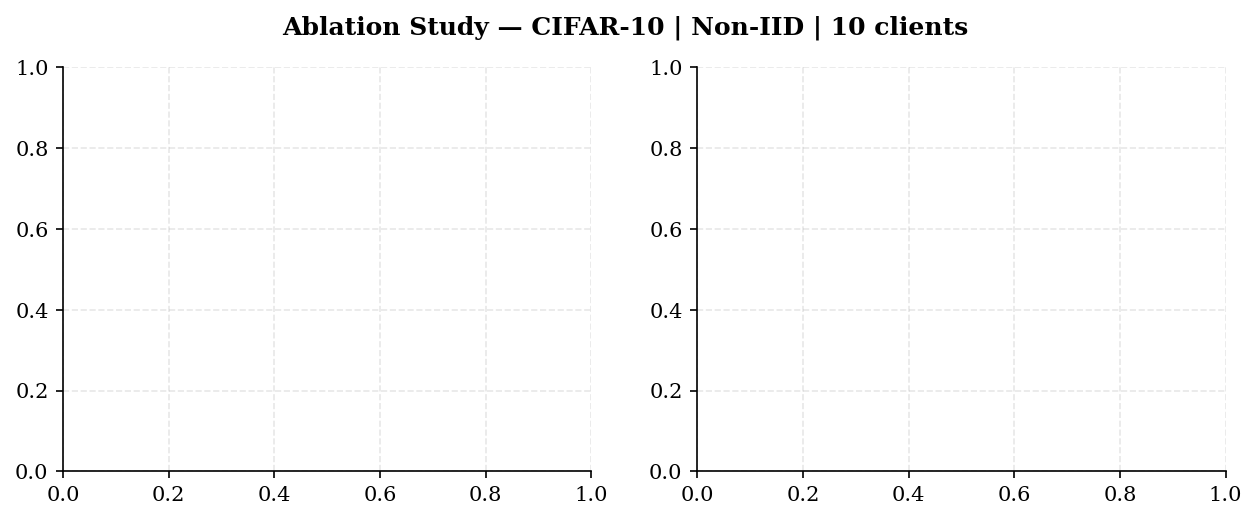

In [6]:
import matplotlib, matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family':'serif','font.serif':['Times New Roman','DejaVu Serif'],
    'font.size':11,'axes.titlesize':12,'axes.labelsize':11,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':9,
    'figure.dpi':150,'axes.grid':True,'grid.alpha':0.3,
    'grid.linestyle':'--','axes.spines.top':False,'axes.spines.right':False,
})

COLORS = {
    'topk_noef'  : '#2166ac',
    'topk_ef'    : '#d6604d',
    'topk_ef_hk' : '#f4a582',
    'feds'       : '#1a9641',
}
LABELS = {
    'topk_noef'  : 'Top-K (baseline)',
    'topk_ef'    : 'Top-K + EF',
    'topk_ef_hk' : 'Top-K + EF + Het-K',
    'feds'       : 'FEDS (Ours)',
}
LS = {'fedavg':':','topk_ef':'-.','topk_ef_hk':'--','feds':'-'}
MK = {'fedavg':'s','topk_ef':'D','topk_ef_hk':'^','feds':'o'}
EV = max(1, NUM_ROUNDS//10)
W  = EMA_SMOOTH

def ema_smooth(vals, window=10):
    alpha=2.0/(window+1); out=[vals[0]]
    for v in vals[1:]: out.append(alpha*v+(1-alpha)*out[-1])
    return out

def save_fig(name):
    for ext in ['pdf','png']:
        plt.savefig(f'{RESULTS_DIR}/figures/{name}.{ext}',
                    bbox_inches='tight',dpi=300 if ext=='png' else None)
    print(f'Saved {name}')

# Fig 1: Accuracy curves
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
fig.suptitle(f'Ablation Study — CIFAR-10 | Non-IID | 10 clients',
             fontsize=12,fontweight='bold')
for m,log in all_logs.items():
    r=log['round']
    acc_sm=ema_smooth([a*100 for a in log['accuracy']],W)
    loss_sm=ema_smooth(log['loss'],W)
    axes[0].plot(r,[a*100 for a in log['accuracy']],
                color=COLORS[m],alpha=0.15,lw=0.8,ls=LS[m])
    axes[1].plot(r,log['loss'],
                color=COLORS[m],alpha=0.15,lw=0.8,ls=LS[m])
    kw=dict(color=COLORS[m],ls=LS[m],lw=2,label=LABELS[m],
            marker=MK[m],markevery=EV,ms=5)
    axes[0].plot(r,acc_sm,**kw)
    axes[1].plot(r,loss_sm,**kw)
axes[0].set(xlabel='Round',ylabel='Test Accuracy (%)',title='(a) Test Accuracy')
axes[0].legend(loc='lower right',fontsize=8)
axes[1].set(xlabel='Round',ylabel='Test Loss',title='(b) Test Loss')
axes[1].legend(loc='upper right',fontsize=8)
plt.tight_layout(); save_fig('fig_ablation_acc_loss'); plt.show()

# Fig 2: Bar chart of best accuracy per variant
fig,ax=plt.subplots(figsize=(6,4))
methods_ordered=['topk_noef','topk_ef','topk_ef_hk','feds']
accs=[max(all_logs[m]['accuracy'])*100 for m in methods_ordered]
bars=ax.bar([LABELS[m] for m in methods_ordered], accs,
            color=[COLORS[m] for m in methods_ordered],
            edgecolor='white',linewidth=0.5,alpha=0.85)
ax.bar_label(bars,fmt='%.2f%%',padding=3,fontsize=9)
ax.set_ylabel('Best Test Accuracy (%)')
ax.set_title('Ablation: Component Contribution — CIFAR-10')
ax.set_ylim(0, max(accs)*1.12)
plt.xticks(rotation=15,ha='right',fontsize=9)
plt.tight_layout(); save_fig('fig_ablation_bar'); plt.show()
print('All ablation figures saved')


## Cell 7 - LaTeX Table

In [ ]:
import pandas as pd

LABELS_SHORT = {
    'topk_noef'  : 'Top-K (no EF)',
    'topk_ef'    : 'Top-K + EF',
    'topk_ef_hk' : 'Top-K + EF + Het-K',
    'feds'       : 'FEDS (Ours)',
}
d=next(iter(all_logs.values()))['total_params']
rows=[]
for m in ['topk_noef','topk_ef','topk_ef_hk','feds']:
    log=all_logs[m]; acc=np.array(log['accuracy']); km=np.mean(log['k_mean'])
    rows.append({
        'Method'         : LABELS_SHORT[m],
        'EF'             : 'Y' if 'ef' in m or m=='feds' else 'N',
        'Het-K'          : 'Y' if 'hk' in m or m=='feds' else 'N',
        'Var. Priority'  : 'Y' if m=='feds' else 'N',
        'Best Acc (%)'   : f'{acc.max()*100:.2f}',
        'Final Acc (%)'  : f'{acc[-1]*100:.2f}',
        'Comm. Saving'   : f'{(1-km/d)*100:.1f}%',
    })
df=pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv(f'{RESULTS_DIR}/tables/ablation_CIFAR10.csv',index=False)
latex=df.to_latex(index=False,escape=False,
    caption='Ablation study on CIFAR-10. EF=Error Feedback, Het-K=Heterogeneous K, Var.=Variance Priority.',
    label='tab:ablation')
latex=latex.replace('FEDS (Ours)','\\textbf{FEDS (Ours)}')
print('\n── LaTeX ──'); print(latex)
with open(f'{RESULTS_DIR}/tables/ablation_CIFAR10.tex','w') as f: f.write(latex)


## Cell 8 - Download

In [ ]:
import zipfile, glob
zname='results_ablation_CIFAR10.zip'
with zipfile.ZipFile(zname,'w',zipfile.ZIP_DEFLATED) as zf:
    for p in glob.glob(f'{RESULTS_DIR}/**/*',recursive=True):
        if os.path.isfile(p): zf.write(p); print(f'  + {p}')
print(f'\n{zname}  ({os.path.getsize(zname)/1e6:.1f} MB)')
if IS_COLAB:
    from google.colab import files; files.download(zname)
elif IS_KAGGLE:
    import shutil; shutil.copy(zname,f'/kaggle/working/{zname}')
    print('Download from Output tab')
